<a href="https://colab.research.google.com/github/muhammad-siddique-research/financial-risk-ai/blob/main/05_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Risk Prediction Using Econometric and Machine Learning Approaches

## Predictive Modeling

This notebook develops and evaluates predictive models for corporate bankruptcy risk using financial indicators.

Models implemented:

1. Logistic Regression (Econometric baseline)
2. Random Forest Classifier
3. XGBoost Classifier

Performance is evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Modeling environment initialized successfully")

Modeling environment initialized successfully


In [3]:
base_url = "https://raw.githubusercontent.com/muhammad-siddique-research/financial-risk-ai/main/data/processed/"

X_train = pd.read_csv(base_url + "X_train_scaled.csv")
X_test = pd.read_csv(base_url + "X_test_scaled.csv")

y_train = pd.read_csv(base_url + "y_train.csv").squeeze()
y_test = pd.read_csv(base_url + "y_test.csv").squeeze()


print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5455, 76)
Testing data: (1364, 76)


In [4]:
# Logistic Regression Model

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model

log_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [5]:
# Predictions

y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]


print("Predictions generated successfully")

Predictions generated successfully


In [6]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("Precision:",
      precision_score(y_test, y_pred_log))

print("Recall:",
      recall_score(y_test, y_pred_log))

print("F1 Score:",
      f1_score(y_test, y_pred_log))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_log))

Accuracy: 0.9618768328445748
Precision: 0.3
Recall: 0.13636363636363635
F1 Score: 0.1875
ROC-AUC: 0.8694214876033057


In [7]:
print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1320
           1       0.30      0.14      0.19        44

    accuracy                           0.96      1364
   macro avg       0.64      0.56      0.58      1364
weighted avg       0.95      0.96      0.95      1364



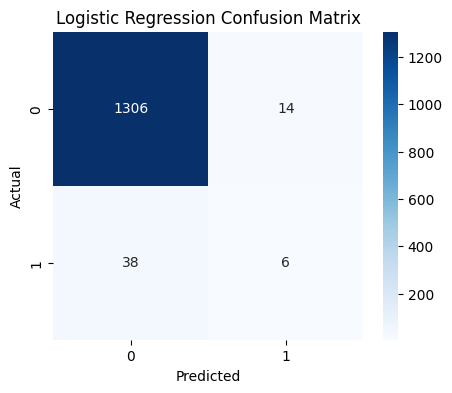

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred_log
)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier


# Initialize Random Forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)


# Train model

rf_model.fit(
    X_train,
    y_train
)


print("Random Forest trained successfully")

Random Forest trained successfully


In [10]:
# Random Forest predictions

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]


print("Random Forest predictions generated")

Random Forest predictions generated


In [11]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.9699413489736071
Precision: 0.6363636363636364
Recall: 0.1590909090909091
F1 Score: 0.2545454545454545
ROC-AUC: 0.9418302341597795


In [12]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1320
           1       0.64      0.16      0.25        44

    accuracy                           0.97      1364
   macro avg       0.80      0.58      0.62      1364
weighted avg       0.96      0.97      0.96      1364



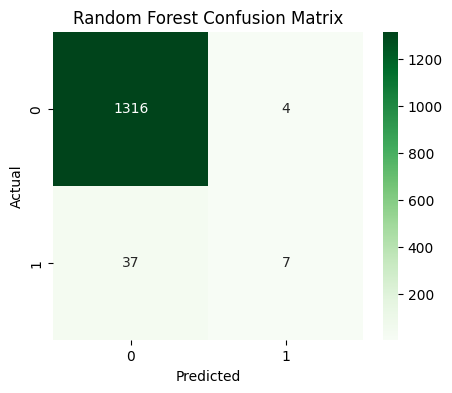

In [13]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
# Feature importance

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


importance.head(15)

,Feature,Importance
10,Persistent EPS in the Last Four Seasons,0.072068
28,Borrowing dependency,0.066373
26,Debt ratio %,0.054503
54,Retained Earnings to Total Assets,0.053690
55,Total income/Total expense,0.052351
75,Equity to Liability,0.050600
71,Net Income to Stockholder's Equity,0.045937
24,Interest Expense Ratio,0.039268
3,Non-industry income and expenditure/revenue,0.035980
0,ROA(C) before interest and depreciation before...,0.034391


In [15]:
!pip install xgboost

In [16]:
from xgboost import XGBClassifier

print("XGBoost imported successfully")

XGBoost imported successfully


In [17]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)


xgb_model.fit(
    X_train,
    y_train
)


print("XGBoost trained successfully")

XGBoost trained successfully


In [18]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]


print("XGBoost predictions generated")

XGBoost predictions generated


In [19]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("Precision:",
      precision_score(y_test, y_pred_xgb))

print("Recall:",
      recall_score(y_test, y_pred_xgb))

print("F1 Score:",
      f1_score(y_test, y_pred_xgb))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_xgb))

Accuracy: 0.9699413489736071
Precision: 0.5714285714285714
Recall: 0.2727272727272727
F1 Score: 0.36923076923076925
ROC-AUC: 0.940771349862259


In [20]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1320
           1       0.57      0.27      0.37        44

    accuracy                           0.97      1364
   macro avg       0.77      0.63      0.68      1364
weighted avg       0.96      0.97      0.96      1364



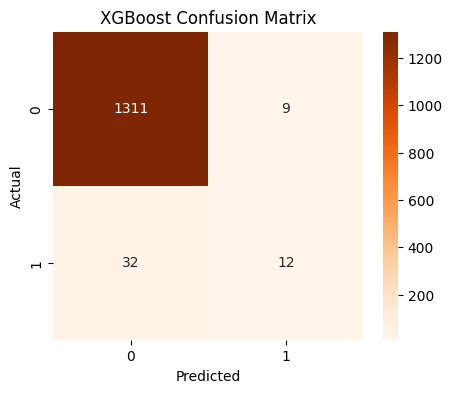

In [21]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})


xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)


xgb_importance.head(15)

,Feature,Importance
71,Net Income to Stockholder's Equity,0.177670
28,Borrowing dependency,0.125578
10,Persistent EPS in the Last Four Seasons,0.064293
26,Debt ratio %,0.041177
54,Retained Earnings to Total Assets,0.031942
55,Total income/Total expense,0.031893
9,Net Value Per Share (B),0.021991
3,Non-industry income and expenditure/revenue,0.020474
67,Current Liability to Current Assets,0.016839
29,Contingent liabilities/Net worth,0.014064


In [23]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})


model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.961877,0.300000,0.136364,0.187500,0.869421
1,Random Forest,0.969941,0.636364,0.159091,0.254545,0.941830
2,XGBoost,0.969941,0.571429,0.272727,0.369231,0.940771


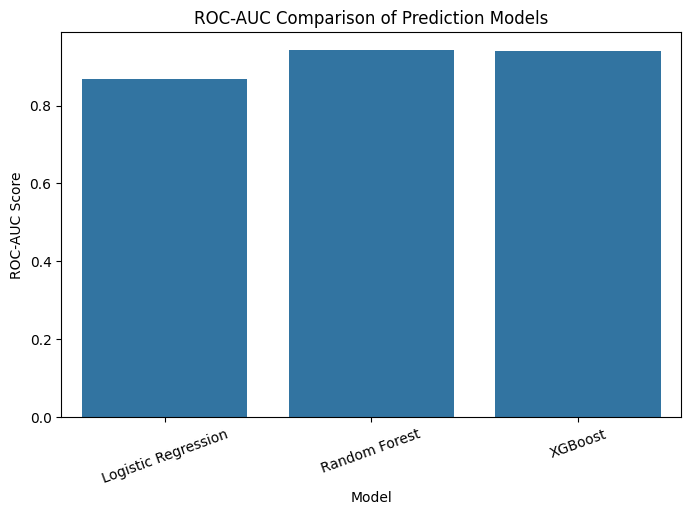

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=model_results,
    x="Model",
    y="ROC-AUC"
)

plt.title("ROC-AUC Comparison of Prediction Models")

plt.ylabel("ROC-AUC Score")

plt.xticks(rotation=20)

plt.show()

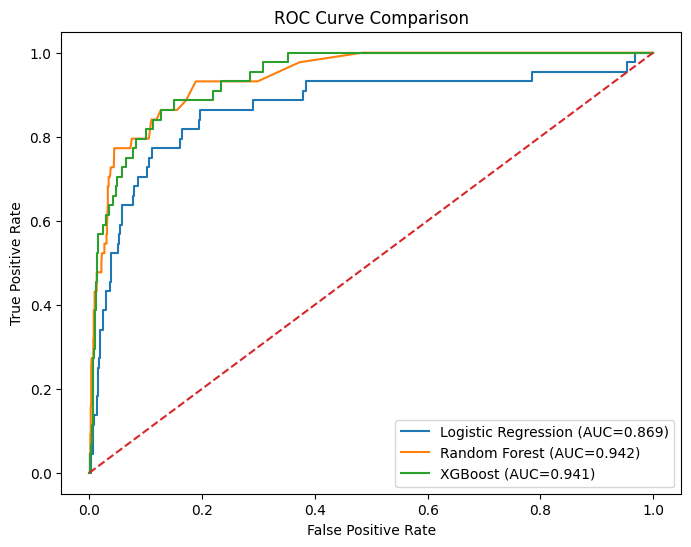

In [25]:
from sklearn.metrics import roc_curve


plt.figure(figsize=(8,6))


models = {
    "Logistic Regression": y_prob_log,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb
}


for name, probabilities in models.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [26]:
!pip install shap

In [27]:
import shap

print("SHAP imported successfully")

SHAP imported successfully


In [28]:
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_test
)

print("SHAP values generated successfully")

SHAP values generated successfully


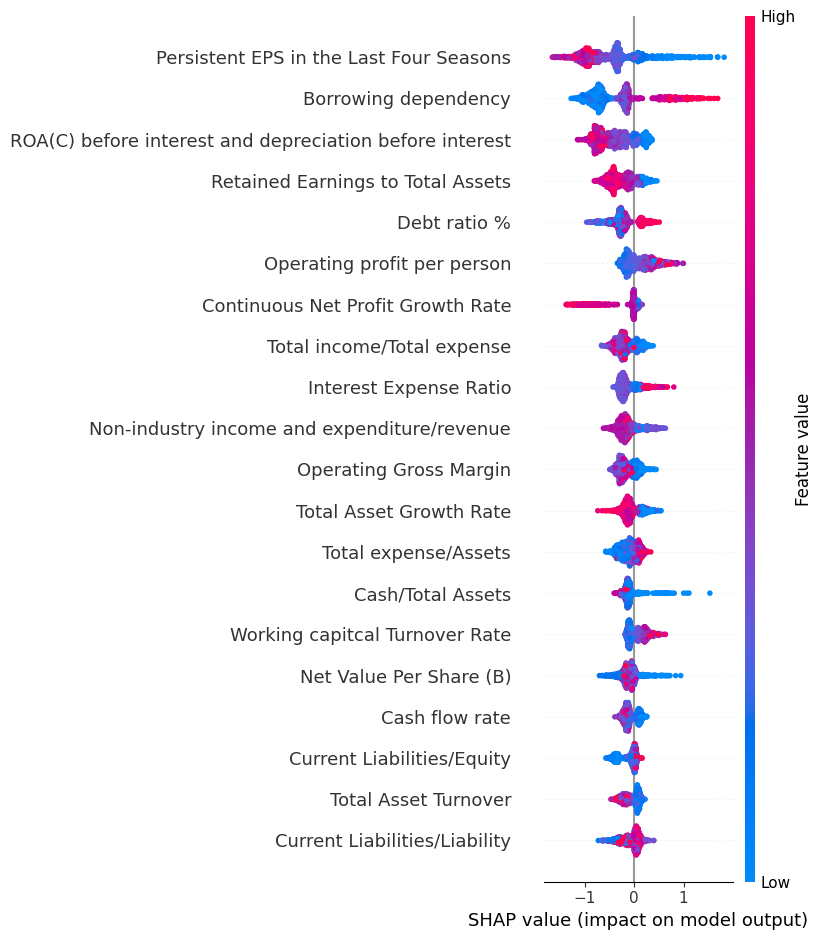

In [29]:
shap.summary_plot(
    shap_values,
    X_test
)

In [30]:
# Calculate mean absolute SHAP importance

shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Importance": np.abs(shap_values).mean(axis=0)
})


shap_importance = shap_importance.sort_values(
    by="SHAP Importance",
    ascending=False
)


shap_importance.head(20)

,Feature,SHAP Importance
10,Persistent EPS in the Last Four Seasons,0.648221
28,Borrowing dependency,0.608757
0,ROA(C) before interest and depreciation before...,0.452138
54,Retained Earnings to Total Assets,0.290980
26,Debt ratio %,0.283864
38,Operating profit per person,0.219464
17,Continuous Net Profit Growth Rate,0.217541
55,Total income/Total expense,0.211499
24,Interest Expense Ratio,0.206291
3,Non-industry income and expenditure/revenue,0.204096


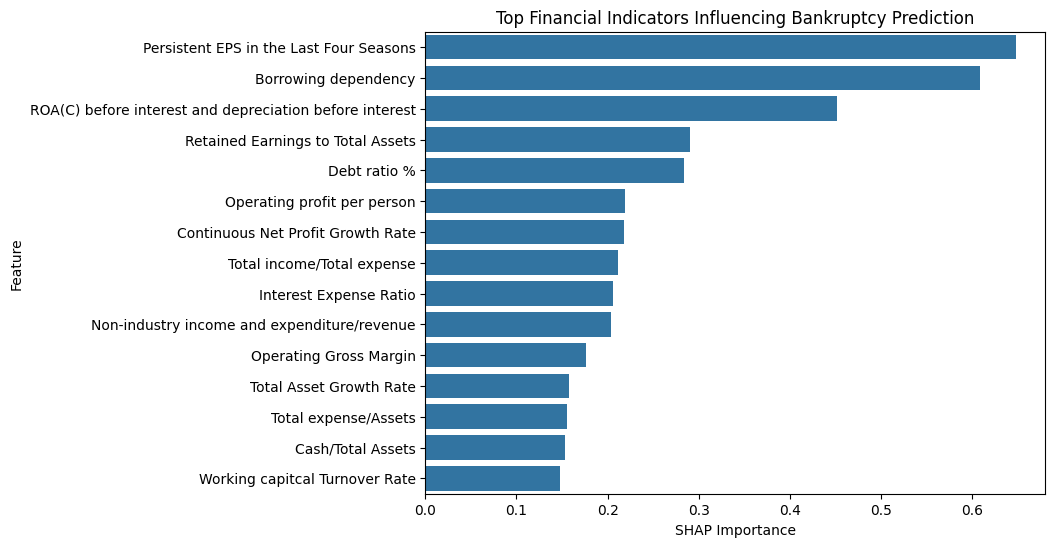

In [31]:
plt.figure(figsize=(8,6))

top_features = shap_importance.head(15)


sns.barplot(
    data=top_features,
    x="SHAP Importance",
    y="Feature"
)


plt.title(
    "Top Financial Indicators Influencing Bankruptcy Prediction"
)


plt.show()

In [34]:
import shap

shap.initjs()

print("SHAP JavaScript initialized")

SHAP JavaScript initialized


In [36]:
shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_index],
    feature_names=X_test.columns
)

.values =
array([-2.77852118e-01, -2.44876027e-01,  2.31298983e-01, -1.10168166e-01,
       -2.41880883e-02, -2.61895061e-02, -1.78315833e-01,  0.00000000e+00,
       -1.32003158e-01, -6.46149591e-02, -4.34650689e-01,  9.72631294e-03,
       -1.11444504e-03,  1.48328602e-01, -4.81195077e-02,  3.68754901e-02,
       -4.26228866e-02,  3.92851047e-02, -1.65053606e-01,  0.00000000e+00,
       -7.90543109e-02,  1.98575091e-02,  3.22082527e-02,  0.00000000e+00,
        1.45449385e-01,  0.00000000e+00, -2.07257062e-01,  1.27707988e-01,
       -1.48929238e-01, -3.18017565e-02, -1.91855747e-02, -2.93958843e-01,
        0.00000000e+00,  0.00000000e+00, -1.05760794e-03, -7.48361871e-02,
        6.85866177e-02, -3.24127963e-04, -6.21070303e-02,  0.00000000e+00,
       -1.72460750e-02,  7.93180913e-02,  3.97482701e-02, -8.81967545e-02,
        0.00000000e+00,  0.00000000e+00,  7.16232881e-02, -2.92176777e-03,
       -1.21840805e-01, -3.73060117e-04, -5.38936667e-02,  1.50570460e-02,
       -4.78761

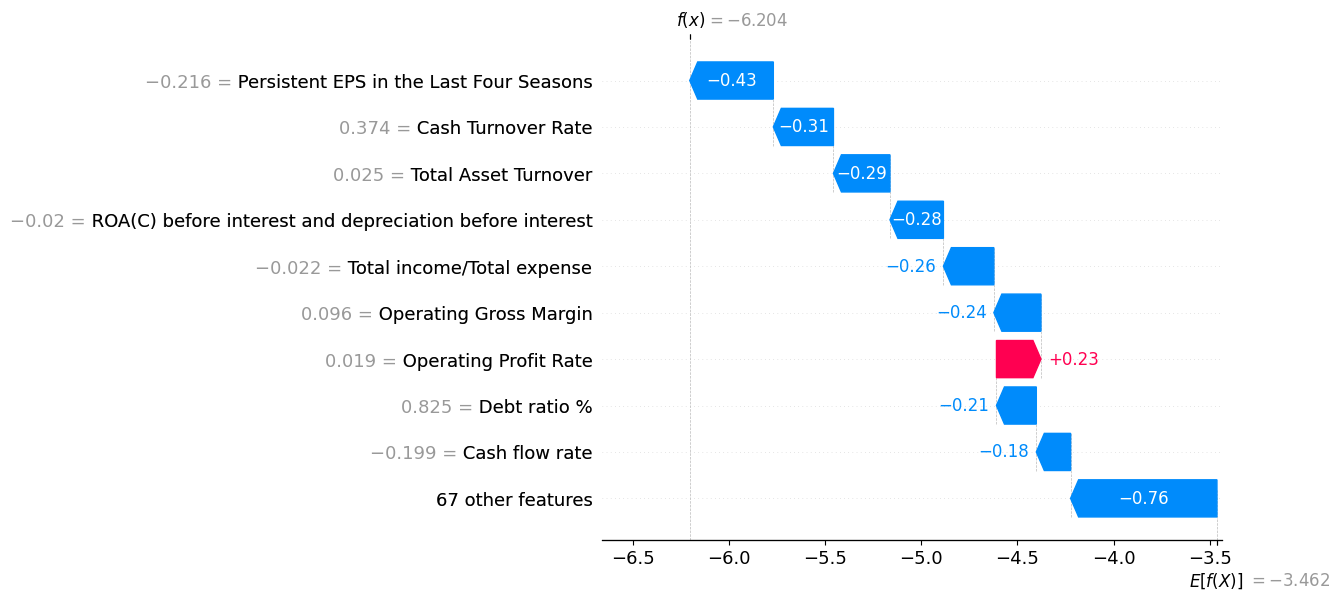

In [38]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)

In [39]:
import os

os.makedirs("results", exist_ok=True)

print("Results folder created")

Results folder created


In [40]:
model_results.to_csv(
    "results/model_comparison.csv",
    index=False
)

shap_importance.to_csv(
    "results/shap_feature_importance.csv",
    index=False
)

print("Results files saved successfully")

Results files saved successfully


In [41]:
from google.colab import files

files.download("results/model_comparison.csv")
files.download("results/shap_feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

This notebook developed and evaluated three predictive models for corporate bankruptcy risk prediction.

The models compared were:

1. Logistic Regression as an econometric baseline model
2. Random Forest as a non-linear machine learning approach
3. XGBoost as an advanced boosting algorithm

Tree-based models demonstrated stronger predictive performance compared with the baseline logistic regression model. SHAP explainability analysis was applied to identify the financial indicators contributing most to bankruptcy risk predictions.

The findings demonstrate the potential of machine learning approaches for supporting financial risk assessment and early warning systems.